In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [2]:
h = h5py.File("H-H1_GWOSC_16KHZ_R1-1257294808-4096.hdf5", "r")
l = h5py.File("L-L1_GWOSC_16KHZ_R1-1257294808-4096.hdf5", "r")

In [3]:
print(h.keys())
print(l.keys())

<KeysViewHDF5 ['meta', 'quality', 'strain']>
<KeysViewHDF5 ['meta', 'quality', 'strain']>


In [4]:
print(h['strain'].keys())
print(l['strain'].keys())

<KeysViewHDF5 ['GWOSCmeta', 'Strain']>
<KeysViewHDF5 ['GWOSCmeta', 'Strain']>


In [5]:
time_h = float(h['meta/GPSstart'][()]) + np.arange(len(h['strain']['Strain']))/16384.
time_l = float(l['meta/GPSstart'][()]) + np.arange(len(l['strain']['Strain']))/16384.

In [6]:
h_strain = h['strain']['Strain'][:]
l_strain = l['strain']['Strain'][:]

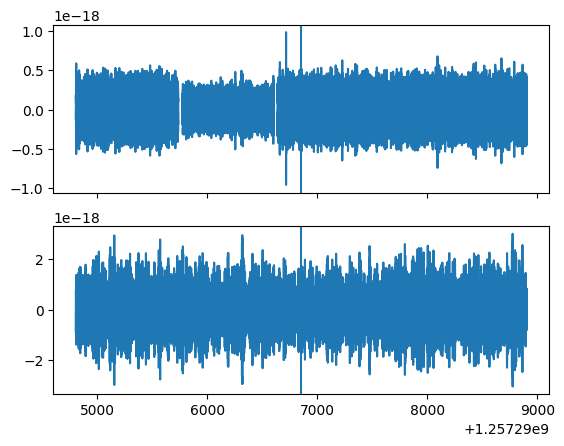

In [7]:
fig, axes = plt.subplots(2, 1, sharex=True)
axes[0].plot(time_h, h_strain)
axes[1].plot(time_l, l_strain)

axes[0].axvline(x=1257296855.2)
axes[1].axvline(x=1257296855.2)

In [8]:
has_nan = np.isnan(h_strain).any()
print(f"Contains NaN: {has_nan}")

Contains NaN: True


In [9]:
has_nan = np.isnan(l_strain).any()
print(f"Contains NaN: {has_nan}")

Contains NaN: False


In [10]:
bad_times = time_h[np.where(h_strain!=h_strain)[0]]
bad_times

array([1.25729574e+09, 1.25729574e+09, 1.25729574e+09, ...,
       1.25729664e+09, 1.25729664e+09, 1.25729664e+09], shape=(1212416,))

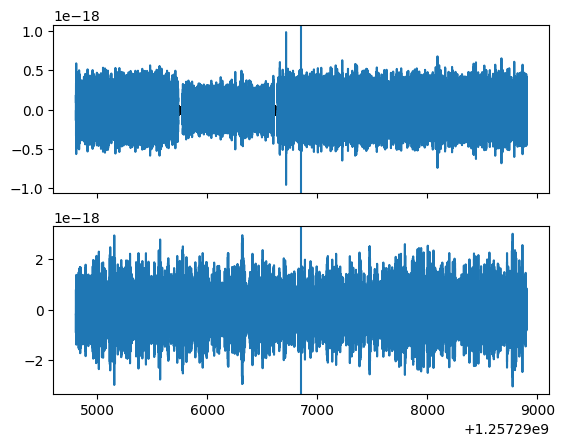

In [11]:
fig, axes = plt.subplots(2, 1, sharex=True)
axes[0].plot(time_h, h_strain)
axes[0].scatter(bad_times, np.zeros_like(bad_times), marker='x', color='black')
axes[1].plot(time_l, l_strain)

axes[0].axvline(x=1257296855.2)
axes[1].axvline(x=1257296855.2)

In [13]:
print(max(bad_times))

1257296640.999939


In [15]:
bad_strain = np.where(h_strain!=h_strain)[0]
bad_strain

array([15220736, 15220737, 15220738, ..., 30031869, 30031870, 30031871],
      shape=(1212416,))

In [16]:
h_strain[15220736]

np.float64(nan)

In [17]:
h_strain[15220735]

np.float64(-1.4440973630290999e-19)

In [18]:
print(max(bad_strain))

30031871


In [22]:
print(time_h[30031871])
print(time_h[30031872])

1257296640.999939
1257296641.0


In [24]:
h_strain[30031872]

np.float64(-5.679488181645556e-20)